# Iris Dataset Prediction With KNN

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

data_path = 'data/Iris.csv'
raw_df = pd.read_csv(data_path)
df = raw_df.copy().drop('Id', axis = 1)



## Checking the dataset

In [4]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
(150, 5)


## Preprocessing

In [5]:
X = df.drop('Species', axis = 1).to_numpy()
y = df['Species'].to_numpy()

indices = np.arange(len(X))
np.random.shuffle(indices)

X_train = X[indices][:120]
y_train = y[indices][:120]

X_test = X[indices][120:]
y_test = y[indices][120:]


mean = X_train.mean(axis = 0)
std = X_train.std(axis = 0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std




## Function

In [6]:
def Euclidean_Compute(v1, v2):
    return np.sqrt(np.sum((v2-v1)** 2))

    

## KNN Class

In [7]:
class KNN:
    def __init__(self, k):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, newpoints):
        prediction  = [self.predict_class(new_point) for new_point in newpoints]

        return np.array(prediction)

    def predict_class(self, new_point):
        distances = [Euclidean_Compute(point, new_point) for point in self.X_train]

        k_nearest_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

        most_common_label = Counter(k_nearest_labels).most_common(1)[0][0]
        
        return most_common_label

## Predicting

In [13]:
knn_test = KNN(5)
knn_test.fit(X_train_scaled, y_train)
predictions = knn_test.predict(X_test_scaled)


## Accuracy 

In [14]:
print(round(accuracy_score(y_test, predictions), 2))

0.97


In [15]:
print(classification_report(y_test, predictions))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.92      1.00      0.96        12
 Iris-virginica       1.00      0.89      0.94         9

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



## Selecting K

Text(0, 0.5, 'Accuracy')

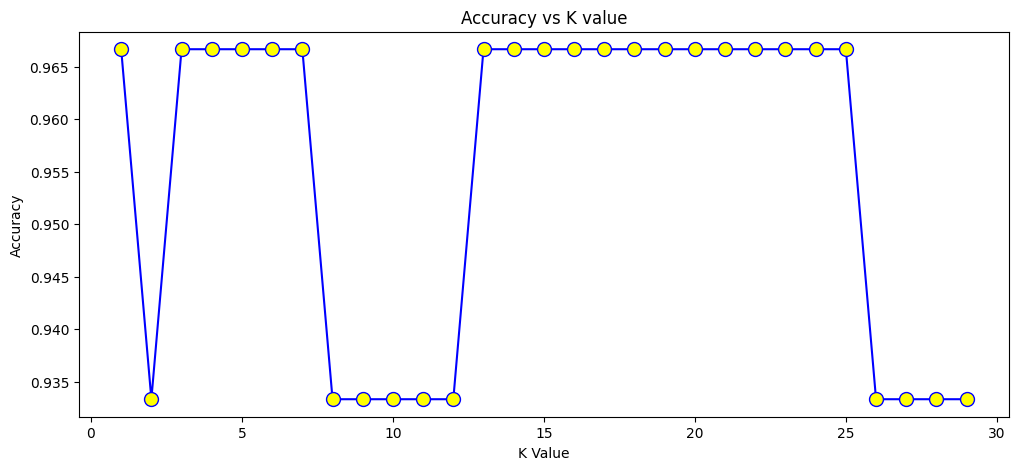

In [16]:
error = []
for i in range(1,30):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error.append(accuracy_score(y_test, pred_i))


plt.figure(figsize = (12,5))
plt.plot(range(1,30), error, color = 'blue', marker = 'o', markerfacecolor = 'yellow', markersize = 10)
plt.title('Accuracy vs K value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')

## Decision Boundary

In [20]:
PetalData_Train = df[['PetalLengthCm', 'PetalWidthCm']].to_numpy()[indices][:120]
PetalData_Test = df[['PetalLengthCm', 'PetalWidthCm']].to_numpy()[indices][120:]

petal_mean = PetalData_Train.mean(axis = 0)
petal_std = PetalData_Train.std(axis = 0)

PetalData_Train_scaled = (PetalData_Train - petal_mean) / petal_std
PetalData_Test = (PetalData_Test - petal_mean) / petal_std

knn_test2 = KNN(5)
knn_test2.fit(PetalData_Train, y_train)

x_range = np.linspace(df['PetalLengthCm'].min(), df['PetalLengthCm'].max() , 300)
y_range = np.linspace(df['PetalWidthCm'].min(), df['PetalWidthCm'].max() , 300)

X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

points = np.column_stack([X_mesh.ravel(), Y_mesh.ravel()])

pred = knn_test2.predict(points)

label_map = {'Iris-setosa': 0, 'Iris-versicolor' : 1,  'Iris-virginica' : 2}
pred_mapped = np.array([label_map[p] for p in pred])

pred_grid = pred_mapped.reshape(X_mesh.shape)





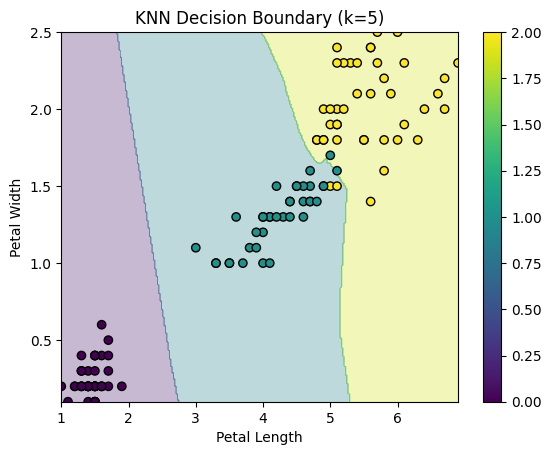

In [22]:
plt.contourf(X_mesh, Y_mesh, pred_grid, alpha=0.3)
plt.scatter(PetalData_Train[:, 0], PetalData_Train[:, 1], c=[label_map[label] for label in y_train], edgecolors='k')
plt.colorbar()
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('KNN Decision Boundary (k=5)')
plt.show()